In [1]:
import sys

print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Python executable: d:\Projects\CyberTwin_ML\.venv\Scripts\python.exe


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# CyberTwin ML — Behavioral Risk & Anomaly Detection

## Objective

This notebook develops the machine learning component of CyberTwin.

The ML module analyzes simulated enterprise user behavior to:

1. Predict behavioral cybersecurity risk.
2. Detect anomalous user behavior.
3. Explain the main factors contributing to the risk prediction.

## Behavioral Features

- failed_logins
- login_hour
- new_devices
- downloads_per_day
- external_shares
- sensitive_file_access
- privilege_requests

## ML Components

- Supervised Risk Classification
- Unsupervised Anomaly Detection
- Model Explainability

## Integration

The ML module will eventually provide predictions to the CyberTwin backend,
which combines behavioral intelligence with attack-path simulation,
asset criticality, and security controls.

In [8]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)
print("Processed data folder:", PROCESSED_DATA_DIR)

Project root: d:\Projects\CyberTwin_ML
Raw data folder: d:\Projects\CyberTwin_ML\data\raw
Processed data folder: d:\Projects\CyberTwin_ML\data\processed


In [9]:
N_SAMPLES = 10_000

print(f"Generating {N_SAMPLES:,} simulated behavioral records.")

Generating 10,000 simulated behavioral records.


In [10]:
FEATURES = [
    "failed_logins",
    "login_hour",
    "new_devices",
    "downloads_per_day",
    "external_shares",
    "sensitive_file_access",
    "privilege_requests"
]

print("Features:")
for feature in FEATURES:
    print("-", feature)

Features:
- failed_logins
- login_hour
- new_devices
- downloads_per_day
- external_shares
- sensitive_file_access
- privilege_requests


In [11]:
rng = np.random.default_rng(42)

# 70% normal, 30% risky
risk_state = rng.choice(
    [0, 1],
    size=N_SAMPLES,
    p=[0.70, 0.30]
)

data = pd.DataFrame({
    "risk_state": risk_state
})

data.head()

,risk_state
0,1
1,0
2,1
3,0
4,0


In [12]:
data["failed_logins"] = np.where(
    data["risk_state"] == 0,
    rng.poisson(lam=1.5, size=N_SAMPLES),
    rng.poisson(lam=4.5, size=N_SAMPLES)
)

data["failed_logins"] = data["failed_logins"].clip(0, 20)

In [13]:
normal_hours = rng.normal(
    loc=13,
    scale=3.5,
    size=N_SAMPLES
)

risky_hours = rng.normal(
    loc=3,
    scale=5,
    size=N_SAMPLES
)

data["login_hour"] = np.where(
    data["risk_state"] == 0,
    normal_hours,
    risky_hours
)

data["login_hour"] = np.round(data["login_hour"]) % 24
data["login_hour"] = data["login_hour"].astype(int)

In [14]:
data["new_devices"] = np.where(
    data["risk_state"] == 0,
    rng.poisson(lam=0.3, size=N_SAMPLES),
    rng.poisson(lam=1.5, size=N_SAMPLES)
)

data["new_devices"] = data["new_devices"].clip(0, 8)

In [15]:
data["downloads_per_day"] = np.where(
    data["risk_state"] == 0,
    rng.lognormal(mean=3.2, sigma=0.6, size=N_SAMPLES),
    rng.lognormal(mean=4.4, sigma=0.8, size=N_SAMPLES)
)

data["downloads_per_day"] = np.round(
    data["downloads_per_day"]
).astype(int)

data["downloads_per_day"] = data["downloads_per_day"].clip(0, 2000)

In [16]:
data["external_shares"] = np.where(
    data["risk_state"] == 0,
    rng.poisson(lam=1.0, size=N_SAMPLES),
    rng.poisson(lam=5.0, size=N_SAMPLES)
)

data["external_shares"] = data["external_shares"].clip(0, 50)

In [17]:
data["sensitive_file_access"] = np.where(
    data["risk_state"] == 0,
    rng.poisson(lam=3.0, size=N_SAMPLES),
    rng.poisson(lam=9.0, size=N_SAMPLES)
)

data["sensitive_file_access"] = data[
    "sensitive_file_access"
].clip(0, 100)

In [18]:
data["privilege_requests"] = np.where(
    data["risk_state"] == 0,
    rng.poisson(lam=0.3, size=N_SAMPLES),
    rng.poisson(lam=1.5, size=N_SAMPLES)
)

data["privilege_requests"] = data[
    "privilege_requests"
].clip(0, 10)

In [19]:
risk_score = (
    0.18 * data["failed_logins"] +
    0.15 * data["new_devices"] +
    0.20 * np.log1p(data["downloads_per_day"]) +
    0.20 * data["external_shares"] +
    0.15 * data["sensitive_file_access"] +
    0.12 * data["privilege_requests"]
)

# Additional risk for unusual login hours
off_hours = (
    (data["login_hour"] < 6) |
    (data["login_hour"] > 22)
)

risk_score += off_hours.astype(int) * 1.5

# Add controlled randomness so the label is not a perfect formula
risk_score += rng.normal(
    loc=0,
    scale=1.5,
    size=N_SAMPLES
)

threshold = np.percentile(risk_score, 70)

data["label"] = (risk_score >= threshold).astype(int)

In [20]:
data.drop(columns=["risk_state"], inplace=True)

In [21]:
data.head(10)

,failed_logins,login_hour,new_devices,downloads_per_day,external_shares,sensitive_file_access,privilege_requests,label
0,4,0,1,132,3,9,1,1
1,0,8,0,16,1,1,0,0
2,10,2,0,75,5,11,1,1
3,2,19,0,10,1,5,1,1
4,2,17,0,52,0,1,0,1
5,5,15,4,54,5,8,0,1
6,7,23,2,241,3,8,2,1
7,1,23,3,52,6,11,0,0
8,2,15,0,36,3,3,0,0
9,1,22,0,16,0,4,0,0


In [22]:
data.insert(
    0,
    "user_id",
    [f"USER_{i:05d}" for i in range(1, N_SAMPLES + 1)]
)

data.head()

,user_id,failed_logins,login_hour,new_devices,downloads_per_day,external_shares,sensitive_file_access,privilege_requests,label
0,USER_00001,4,0,1,132,3,9,1,1
1,USER_00002,0,8,0,16,1,1,0,0
2,USER_00003,10,2,0,75,5,11,1,1
3,USER_00004,2,19,0,10,1,5,1,1
4,USER_00005,2,17,0,52,0,1,0,1


In [23]:
print("Shape:", data.shape)

print("\nColumns:")
print(data.columns.tolist())

print("\nMissing values:")
print(data.isnull().sum())

print("\nClass distribution:")
print(data["label"].value_counts())

print("\nClass percentages:")
print(
    data["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Shape: (10000, 9)

Columns:
['user_id', 'failed_logins', 'login_hour', 'new_devices', 'downloads_per_day', 'external_shares', 'sensitive_file_access', 'privilege_requests', 'label']

Missing values:
user_id                  0
failed_logins            0
login_hour               0
new_devices              0
downloads_per_day        0
external_shares          0
sensitive_file_access    0
privilege_requests       0
label                    0
dtype: int64

Class distribution:
label
0    7000
1    3000
Name: count, dtype: int64

Class percentages:
label
0    70.0
1    30.0
Name: proportion, dtype: float64


In [24]:
output_path = RAW_DATA_DIR / "cybertwin_behavioral_dataset.csv"

data.to_csv(
    output_path,
    index=False
)

print(f"Dataset saved to: {output_path}")

Dataset saved to: d:\Projects\CyberTwin_ML\data\raw\cybertwin_behavioral_dataset.csv


In [25]:
print(data.shape)
print(data["label"].value_counts())
print(data.head())

(10000, 9)
label
0    7000
1    3000
Name: count, dtype: int64
      user_id  failed_logins  login_hour  new_devices  downloads_per_day  \
0  USER_00001              4           0            1                132   
1  USER_00002              0           8            0                 16   
2  USER_00003             10           2            0                 75   
3  USER_00004              2          19            0                 10   
4  USER_00005              2          17            0                 52   

   external_shares  sensitive_file_access  privilege_requests  label  
0                3                      9                   1      1  
1                1                      1                   0      0  
2                5                     11                   1      1  
3                1                      5                   1      1  
4                0                      1                   0      1  


In [26]:
print("===== DATASET VALIDATION =====")

print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]}")

print("\nData types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicate rows:")
print(data.duplicated().sum())

===== DATASET VALIDATION =====
Rows: 10,000
Columns: 9

Data types:
user_id                    str
failed_logins            int64
login_hour               int64
new_devices              int64
downloads_per_day        int64
external_shares          int64
sensitive_file_access    int64
privilege_requests       int64
label                    int64
dtype: object

Missing values:
user_id                  0
failed_logins            0
login_hour               0
new_devices              0
downloads_per_day        0
external_shares          0
sensitive_file_access    0
privilege_requests       0
label                    0
dtype: int64

Duplicate rows:
0


In [27]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
failed_logins,10000.0,2.3762,2.076272,0.0,1.0,2.0,3.00,14.0
login_hour,10000.0,11.6322,5.391700,0.0,8.0,12.0,15.00,23.0
new_devices,10000.0,0.6438,0.963958,0.0,0.0,0.0,1.00,7.0
downloads_per_day,10000.0,54.4750,75.169670,3.0,19.0,32.0,57.25,2000.0
external_shares,10000.0,2.1772,2.374482,0.0,0.0,1.0,3.00,15.0
sensitive_file_access,10000.0,4.7658,3.509442,0.0,2.0,4.0,7.00,24.0
privilege_requests,10000.0,0.6521,0.977528,0.0,0.0,0.0,1.00,7.0
label,10000.0,0.3000,0.458280,0.0,0.0,0.0,1.00,1.0


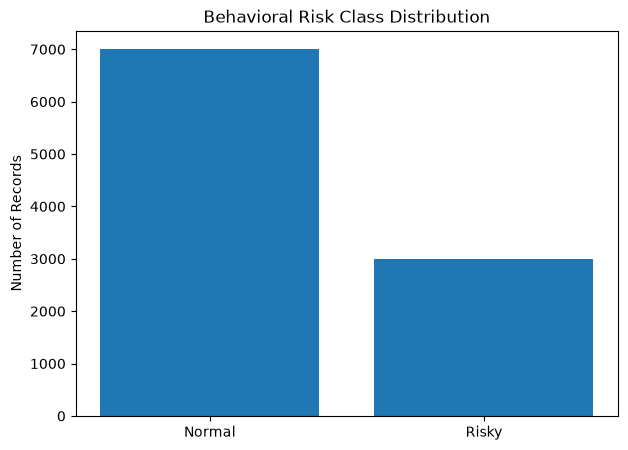

In [28]:
class_counts = data["label"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Normal", "Risky"],
    class_counts.values
)

plt.title("Behavioral Risk Class Distribution")
plt.ylabel("Number of Records")
plt.show()

In [29]:
feature_columns = [
    "failed_logins",
    "login_hour",
    "new_devices",
    "downloads_per_day",
    "external_shares",
    "sensitive_file_access",
    "privilege_requests"
]

data.groupby("label")[feature_columns].mean().T

label,0,1
failed_logins,1.668286,4.028000
login_hour,12.792286,8.925333
new_devices,0.385714,1.246000
downloads_per_day,35.505000,98.738333
external_shares,1.234571,4.376667
sensitive_file_access,3.362857,8.039333
privilege_requests,0.374286,1.300333


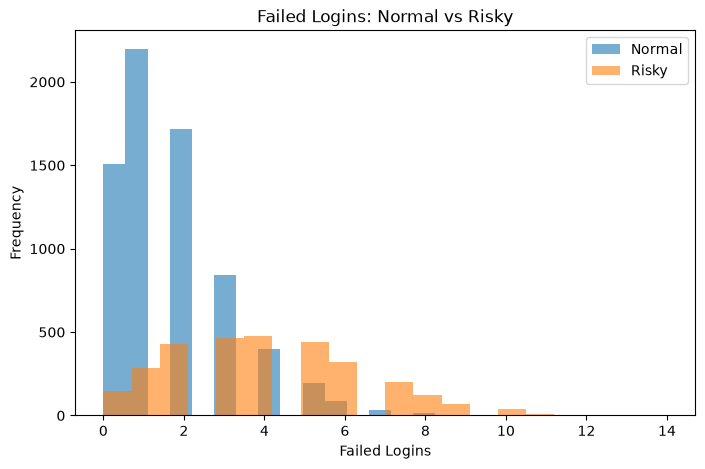

In [30]:
plt.figure(figsize=(8, 5))

for label, name in [(0, "Normal"), (1, "Risky")]:
    subset = data[data["label"] == label]
    
    plt.hist(
        subset["failed_logins"],
        bins=20,
        alpha=0.6,
        label=name
    )

plt.title("Failed Logins: Normal vs Risky")
plt.xlabel("Failed Logins")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [31]:
def compare_feature(feature, bins=20):
    plt.figure(figsize=(8, 5))

    for label, name in [(0, "Normal"), (1, "Risky")]:
        subset = data[data["label"] == label]

        plt.hist(
            subset[feature],
            bins=bins,
            alpha=0.6,
            label=name
        )

    plt.title(f"{feature}: Normal vs Risky")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

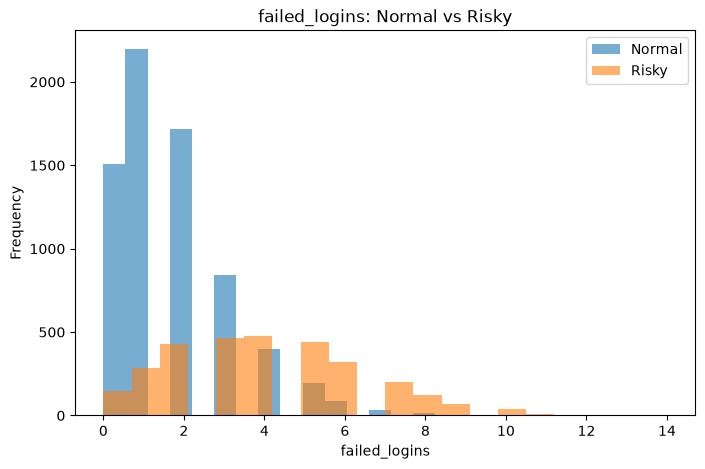

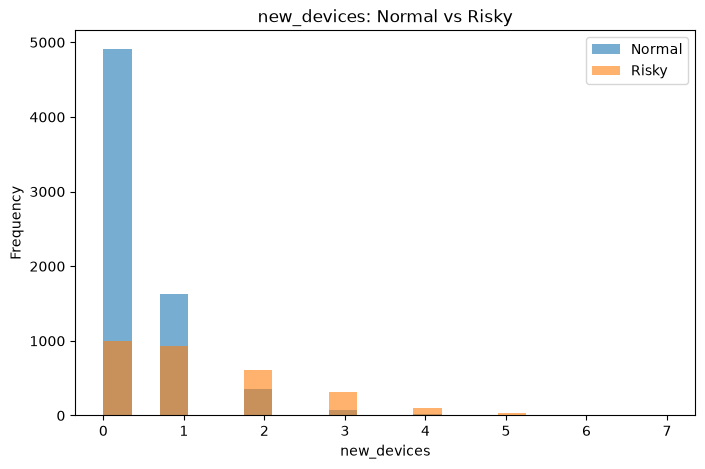

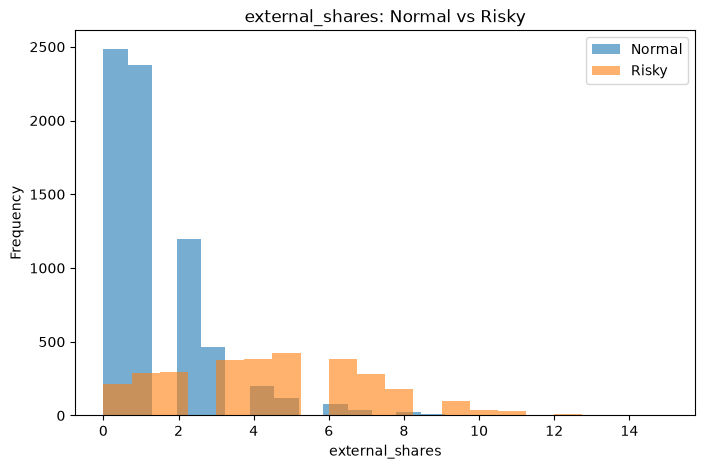

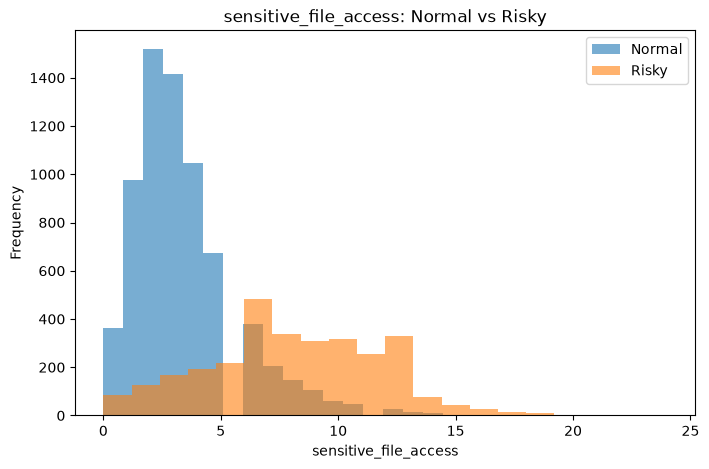

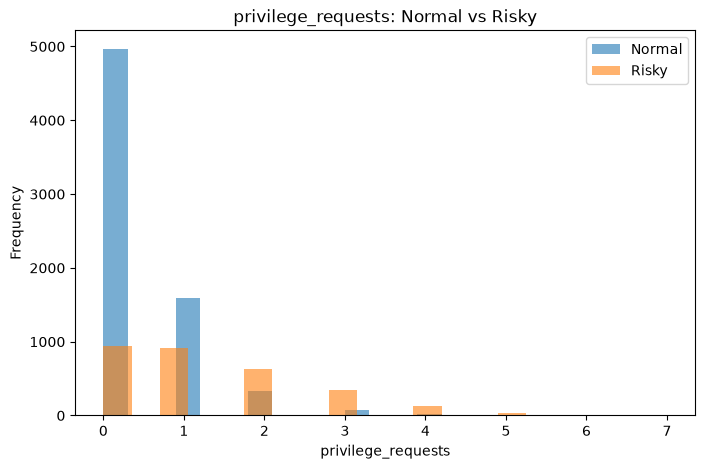

In [32]:
compare_feature("failed_logins")
compare_feature("new_devices")
compare_feature("external_shares")
compare_feature("sensitive_file_access")
compare_feature("privilege_requests")

In [33]:
data["off_hours"] = (
    (data["login_hour"] < 6) |
    (data["login_hour"] > 22)
)

print(
    pd.crosstab(
        data["off_hours"],
        data["label"],
        normalize="columns"
    ).round(3)
)

label          0      1
off_hours              
False      0.968  0.504
True       0.032  0.496


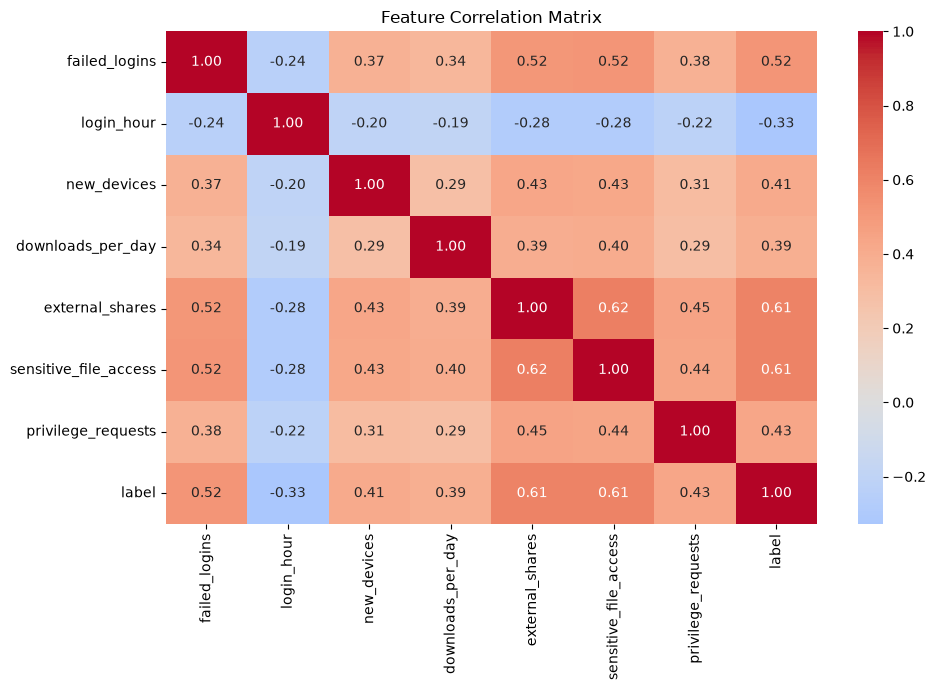

In [34]:
plt.figure(figsize=(10, 7))

correlation = data[
    feature_columns + ["label"]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [35]:
label_correlations = (
    correlation["label"]
    .drop("label")
    .sort_values(key=abs, ascending=False)
)

print(label_correlations)

sensitive_file_access    0.610678
external_shares          0.606432
failed_logins            0.520843
privilege_requests       0.434146
new_devices              0.408993
downloads_per_day        0.385509
login_hour              -0.328681
Name: label, dtype: float64


In [36]:
data.groupby("label")[feature_columns].mean().T

label,0,1
failed_logins,1.668286,4.028000
login_hour,12.792286,8.925333
new_devices,0.385714,1.246000
downloads_per_day,35.505000,98.738333
external_shares,1.234571,4.376667
sensitive_file_access,3.362857,8.039333
privilege_requests,0.374286,1.300333


In [37]:
label_correlations

sensitive_file_access    0.610678
external_shares          0.606432
failed_logins            0.520843
privilege_requests       0.434146
new_devices              0.408993
downloads_per_day        0.385509
login_hour              -0.328681
Name: label, dtype: float64

In [38]:
ml_data = data.copy()

print(ml_data.shape)

(10000, 10)


In [39]:
ml_data["off_hours"] = (
    (ml_data["login_hour"] < 6) |
    (ml_data["login_hour"] > 22)
).astype(int)

In [40]:
ml_data["off_hours"].value_counts()

off_hours
0    8285
1    1715
Name: count, dtype: int64

In [41]:
ml_data["authentication_risk"] = (
    ml_data["failed_logins"] * 0.7 +
    ml_data["new_devices"] * 1.0 +
    ml_data["off_hours"] * 1.5
)

In [42]:
ml_data["data_exposure_risk"] = (
    np.log1p(ml_data["downloads_per_day"]) * 1.2 +
    ml_data["external_shares"] * 1.0 +
    ml_data["sensitive_file_access"] * 0.8
)

In [43]:
ml_data["privilege_risk"] = (
    ml_data["privilege_requests"] * 1.5 +
    ml_data["new_devices"] * 0.5
)

In [44]:
engineered_features = [
    "off_hours",
    "authentication_risk",
    "data_exposure_risk",
    "privilege_risk"
]

ml_data[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
off_hours,10000.0,0.171500,0.376964,0.000000,0.000000,0.00000,0.000000,1.000000
authentication_risk,10000.0,2.564390,2.336546,0.000000,0.700000,1.70000,3.800000,13.600000
data_exposure_risk,10000.0,10.306285,5.286540,1.663553,6.451161,8.19746,14.055733,30.941492
privilege_risk,10000.0,1.300050,1.680276,0.000000,0.000000,0.50000,2.000000,11.500000


In [45]:
ml_data.head()

,user_id,failed_logins,login_hour,new_devices,downloads_per_day,external_shares,sensitive_file_access,privilege_requests,label,off_hours,authentication_risk,data_exposure_risk,privilege_risk
0,USER_00001,4,0,1,132,3,9,1,1,1,5.3,16.068419,2.0
1,USER_00002,0,8,0,16,1,1,0,0,0,0.0,5.199856,0.0
2,USER_00003,10,2,0,75,5,11,1,1,1,8.5,18.996880,1.5
3,USER_00004,2,19,0,10,1,5,1,1,0,1.4,7.877474,1.5
4,USER_00005,2,17,0,52,0,1,0,1,0,1.4,5.564350,0.0


In [46]:
MODEL_FEATURES = [
    "failed_logins",
    "login_hour",
    "new_devices",
    "downloads_per_day",
    "external_shares",
    "sensitive_file_access",
    "privilege_requests",
    "off_hours",
    "authentication_risk",
    "data_exposure_risk",
    "privilege_risk"
]

TARGET = "label"

print("Model features:", len(MODEL_FEATURES))

for feature in MODEL_FEATURES:
    print("-", feature)

Model features: 11
- failed_logins
- login_hour
- new_devices
- downloads_per_day
- external_shares
- sensitive_file_access
- privilege_requests
- off_hours
- authentication_risk
- data_exposure_risk
- privilege_risk


In [47]:
feature_target_corr = (
    ml_data[MODEL_FEATURES + [TARGET]]
    .corr()["label"]
    .drop("label")
    .sort_values(key=abs, ascending=False)
)

print(feature_target_corr)

data_exposure_risk       0.687630
authentication_risk      0.629235
sensitive_file_access    0.610678
external_shares          0.606432
off_hours                0.564149
failed_logins            0.520843
privilege_risk           0.496175
privilege_requests       0.434146
new_devices              0.408993
downloads_per_day        0.385509
login_hour              -0.328681
Name: label, dtype: float64


In [48]:
processed_path = PROCESSED_DATA_DIR / "cybertwin_ml_features.csv"

ml_data.to_csv(
    processed_path,
    index=False
)

print(f"Processed dataset saved to: {processed_path}")

Processed dataset saved to: d:\Projects\CyberTwin_ML\data\processed\cybertwin_ml_features.csv


In [49]:
print("Shape:", ml_data.shape)
print("Features:", MODEL_FEATURES)
print(ml_data[MODEL_FEATURES].head())

Shape: (10000, 13)
Features: ['failed_logins', 'login_hour', 'new_devices', 'downloads_per_day', 'external_shares', 'sensitive_file_access', 'privilege_requests', 'off_hours', 'authentication_risk', 'data_exposure_risk', 'privilege_risk']
   failed_logins  login_hour  new_devices  downloads_per_day  external_shares  \
0              4           0            1                132                3   
1              0           8            0                 16                1   
2             10           2            0                 75                5   
3              2          19            0                 10                1   
4              2          17            0                 52                0   

   sensitive_file_access  privilege_requests  off_hours  authentication_risk  \
0                      9                   1          1                  5.3   
1                      1                   0          0                  0.0   
2                     11          

In [50]:
from sklearn.model_selection import train_test_split

X = ml_data[MODEL_FEATURES]
y = ml_data[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 11)
y shape: (10000,)


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 8000
Testing samples: 2000

Training distribution:
label
0    0.7
1    0.3
Name: proportion, dtype: float64

Testing distribution:
label
0    0.7
1    0.3
Name: proportion, dtype: float64


In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


In [53]:
rf_predictions = rf_model.predict(X_test)

rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

print("Predictions generated.")
print("First 10 probabilities:")
print(rf_probabilities[:10])

Predictions generated.
First 10 probabilities:
[0.07114499 0.04067965 0.23325142 0.33367745 0.07135565 0.79410119
 0.00891453 0.0126455  0.08761255 0.96083333]


In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_auc = roc_auc_score(y_test, rf_probabilities)

print("===== RANDOM FOREST =====")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_predictions,
    target_names=["Normal", "Risky"]
))

===== RANDOM FOREST =====
Accuracy : 0.8750
Precision: 0.8059
Recall   : 0.7683
F1 Score : 0.7867
ROC-AUC  : 0.8785

Classification Report:
              precision    recall  f1-score   support

      Normal       0.90      0.92      0.91      1400
       Risky       0.81      0.77      0.79       600

    accuracy                           0.88      2000
   macro avg       0.85      0.84      0.85      2000
weighted avg       0.87      0.88      0.87      2000



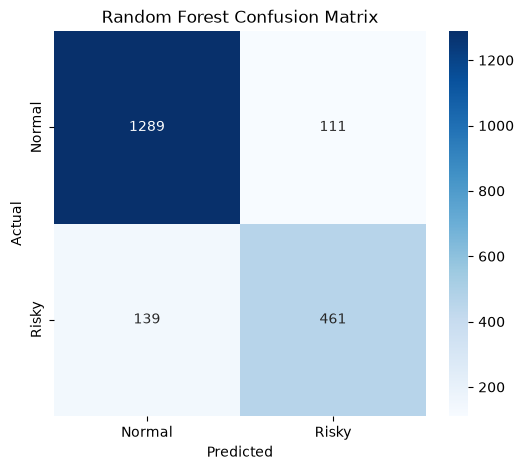

In [55]:
cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Risky"],
    yticklabels=["Normal", "Risky"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [56]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=MODEL_FEATURES
).sort_values(ascending=False)

print(rf_importance)

data_exposure_risk       0.311484
authentication_risk      0.174697
external_shares          0.113919
sensitive_file_access    0.106207
downloads_per_day        0.081051
login_hour               0.073611
off_hours                0.041941
failed_logins            0.039756
privilege_risk           0.033987
privilege_requests       0.012379
new_devices              0.010969
dtype: float64


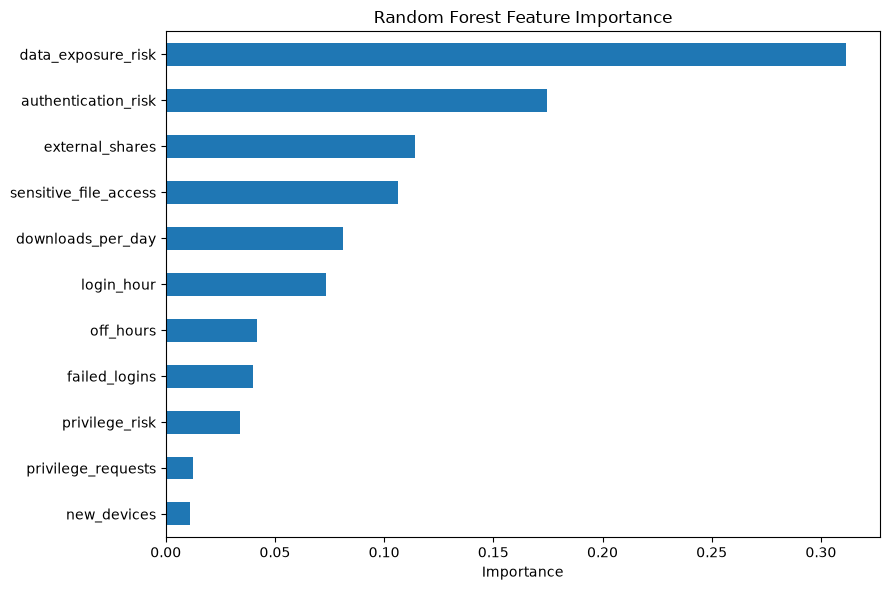

In [57]:
plt.figure(figsize=(9, 6))

rf_importance.sort_values().plot(
    kind="barh"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [58]:
rf_importance

data_exposure_risk       0.311484
authentication_risk      0.174697
external_shares          0.113919
sensitive_file_access    0.106207
downloads_per_day        0.081051
login_hour               0.073611
off_hours                0.041941
failed_logins            0.039756
privilege_risk           0.033987
privilege_requests       0.012379
new_devices              0.010969
dtype: float64

In [59]:
RAW_FEATURES = [
    "failed_logins",
    "login_hour",
    "new_devices",
    "downloads_per_day",
    "external_shares",
    "sensitive_file_access",
    "privilege_requests"
]

X_raw = ml_data[RAW_FEATURES]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Raw feature training shape:", X_train_raw.shape)
print("Raw feature testing shape:", X_test_raw.shape)

Raw feature training shape: (8000, 7)
Raw feature testing shape: (2000, 7)


In [60]:
rf_raw_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_raw_model.fit(X_train_raw, y_train_raw)

rf_raw_predictions = rf_raw_model.predict(X_test_raw)
rf_raw_probabilities = rf_raw_model.predict_proba(X_test_raw)[:, 1]

In [61]:
rf_raw_accuracy = accuracy_score(y_test_raw, rf_raw_predictions)
rf_raw_precision = precision_score(y_test_raw, rf_raw_predictions)
rf_raw_recall = recall_score(y_test_raw, rf_raw_predictions)
rf_raw_f1 = f1_score(y_test_raw, rf_raw_predictions)
rf_raw_auc = roc_auc_score(y_test_raw, rf_raw_probabilities)

print("===== RANDOM FOREST — RAW FEATURES =====")
print(f"Accuracy : {rf_raw_accuracy:.4f}")
print(f"Precision: {rf_raw_precision:.4f}")
print(f"Recall   : {rf_raw_recall:.4f}")
print(f"F1 Score : {rf_raw_f1:.4f}")
print(f"ROC-AUC  : {rf_raw_auc:.4f}")

===== RANDOM FOREST — RAW FEATURES =====
Accuracy : 0.8740
Precision: 0.8000
Recall   : 0.7733
F1 Score : 0.7864
ROC-AUC  : 0.8778


In [62]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Raw Features": [
        rf_raw_accuracy,
        rf_raw_precision,
        rf_raw_recall,
        rf_raw_f1,
        rf_raw_auc
    ],
    "Raw + Engineered": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]
})

comparison

,Metric,Raw Features,Raw + Engineered
0,Accuracy,0.874000,0.875000
1,Precision,0.800000,0.805944
2,Recall,0.773333,0.768333
3,F1,0.786441,0.786689
4,ROC-AUC,0.877779,0.878477


In [63]:
#XGBoost

In [65]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_raw,
    y_train_raw
)

print("XGBoost training complete.")

XGBoost training complete.


In [66]:
xgb_predictions = xgb_model.predict(X_test_raw)

xgb_probabilities = xgb_model.predict_proba(
    X_test_raw
)[:, 1]

print("XGBoost predictions generated.")
print(xgb_probabilities[:10])

XGBoost predictions generated.
[0.05212416 0.04960091 0.08165578 0.2613933  0.0610447  0.834354
 0.04952879 0.02570049 0.04767325 0.9704471 ]


In [67]:
xgb_accuracy = accuracy_score(
    y_test_raw,
    xgb_predictions
)

xgb_precision = precision_score(
    y_test_raw,
    xgb_predictions
)

xgb_recall = recall_score(
    y_test_raw,
    xgb_predictions
)

xgb_f1 = f1_score(
    y_test_raw,
    xgb_predictions
)

xgb_auc = roc_auc_score(
    y_test_raw,
    xgb_probabilities
)

print("===== XGBOOST =====")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

===== XGBOOST =====
Accuracy : 0.8755
Precision: 0.8343
Recall   : 0.7300
F1 Score : 0.7787
ROC-AUC  : 0.8798


In [68]:
model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Random Forest": [
        rf_raw_accuracy,
        rf_raw_precision,
        rf_raw_recall,
        rf_raw_f1,
        rf_raw_auc
    ],
    "XGBoost": [
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1,
        xgb_auc
    ]
})

model_comparison

,Metric,Random Forest,XGBoost
0,Accuracy,0.874000,0.875500
1,Precision,0.800000,0.834286
2,Recall,0.773333,0.730000
3,F1,0.786441,0.778667
4,ROC-AUC,0.877779,0.879789


In [69]:
from sklearn.model_selection import train_test_split

# First: 90% development, 10% final test
X_dev, X_final_test, y_dev, y_final_test = train_test_split(
    X_raw,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

# Second: split development into 80% train / 10% validation
# Relative to the complete dataset this becomes:
# 80% train, 10% validation, 10% test

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=1/9,
    random_state=42,
    stratify=y_dev
)

print("Training:", X_train_final.shape)
print("Validation:", X_val.shape)
print("Final test:", X_final_test.shape)

Training: (8000, 7)
Validation: (1000, 7)
Final test: (1000, 7)


In [70]:
rf_final_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_final_model.fit(
    X_train_final,
    y_train_final
)

rf_val_probabilities = rf_final_model.predict_proba(
    X_val
)[:, 1]

print("Final candidate Random Forest trained.")

Final candidate Random Forest trained.


In [71]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.20, 0.81, 0.05):

    predictions = (
        rf_val_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,precision,recall,f1
0,0.20,0.511538,0.886667,0.648780
1,0.25,0.591837,0.870000,0.704453
2,0.30,0.658915,0.850000,0.742358
3,0.35,0.704225,0.833333,0.763359
4,0.40,0.740299,0.826667,0.781102
5,0.45,0.770440,0.816667,0.792880
6,0.50,0.798046,0.816667,0.807249
7,0.55,0.812081,0.806667,0.809365
8,0.60,0.816327,0.800000,0.808081
9,0.65,0.822300,0.786667,0.804089


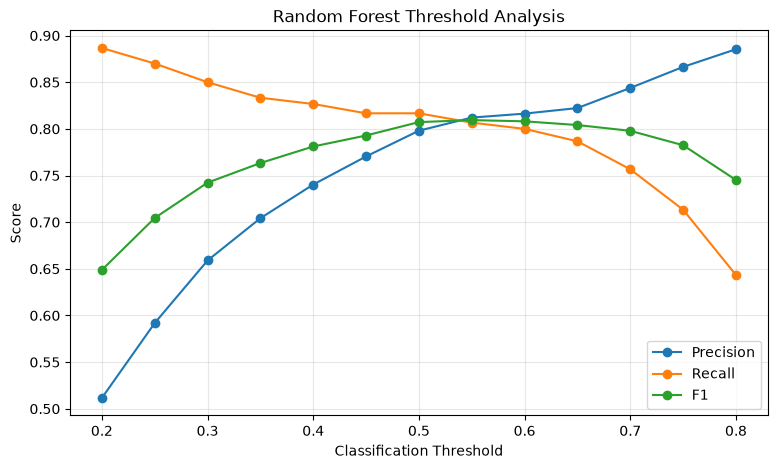

In [72]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Random Forest Threshold Analysis")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [73]:
X_train_full = pd.concat([X_train_final, X_val])
y_train_full = pd.concat([y_train_final, y_val])

print("Final training set:", X_train_full.shape)
print("Final test set:", X_final_test.shape)

Final training set: (9000, 7)
Final test set: (1000, 7)


In [74]:
final_rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

final_rf_model.fit(
    X_train_full,
    y_train_full
)

print("Final Random Forest trained.")

Final Random Forest trained.


In [75]:
final_test_probabilities = final_rf_model.predict_proba(
    X_final_test
)[:, 1]

FINAL_THRESHOLD = 0.55

final_test_predictions = (
    final_test_probabilities >= FINAL_THRESHOLD
).astype(int)

In [76]:
final_accuracy = accuracy_score(
    y_final_test,
    final_test_predictions
)

final_precision = precision_score(
    y_final_test,
    final_test_predictions
)

final_recall = recall_score(
    y_final_test,
    final_test_predictions
)

final_f1 = f1_score(
    y_final_test,
    final_test_predictions
)

final_auc = roc_auc_score(
    y_final_test,
    final_test_probabilities
)

print("======================================")
print("   CYBERTWIN FINAL RISK MODEL")
print("======================================")
print(f"Model     : Random Forest")
print(f"Features  : {len(RAW_FEATURES)} behavioral features")
print(f"Threshold : {FINAL_THRESHOLD}")
print("--------------------------------------")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_auc:.4f}")

   CYBERTWIN FINAL RISK MODEL
Model     : Random Forest
Features  : 7 behavioral features
Threshold : 0.55
--------------------------------------
Accuracy  : 0.8710
Precision : 0.8132
Recall    : 0.7400
F1 Score  : 0.7749
ROC-AUC   : 0.8712


In [77]:
print(
    classification_report(
        y_final_test,
        final_test_predictions,
        target_names=["Normal", "Risky"]
    )
)

              precision    recall  f1-score   support

      Normal       0.89      0.93      0.91       700
       Risky       0.81      0.74      0.77       300

    accuracy                           0.87      1000
   macro avg       0.85      0.83      0.84      1000
weighted avg       0.87      0.87      0.87      1000



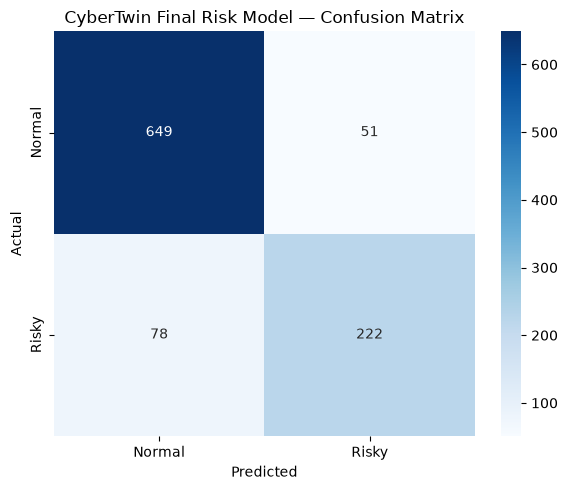

In [78]:
final_cm = confusion_matrix(
    y_final_test,
    final_test_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Risky"],
    yticklabels=["Normal", "Risky"]
)

plt.title("CyberTwin Final Risk Model — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [79]:
risk_scores = final_test_probabilities * 100

In [80]:
from sklearn.ensemble import IsolationForest

# Use only NORMAL behavior to learn the baseline
X_train_normal = X_train_final[
    y_train_final == 0
]

print("Normal training samples:", X_train_normal.shape[0])
print("Features:", X_train_normal.shape[1])

Normal training samples: 5600
Features: 7


In [81]:
isolation_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

isolation_model.fit(X_train_normal)

print("Isolation Forest training complete.")

Isolation Forest training complete.


In [82]:
normal_scores = isolation_model.score_samples(X_train_normal)

print("Minimum score:", normal_scores.min())
print("Maximum score:", normal_scores.max())
print("Mean score:", normal_scores.mean())

Minimum score: -0.7364359114530552
Maximum score: -0.3588236405372288
Mean score: -0.43945688929417415


In [83]:
def anomaly_score(model, X):
    return -model.score_samples(X)

In [84]:
train_anomaly_scores = anomaly_score(
    isolation_model,
    X_train_normal
)

print("Minimum anomaly score:", train_anomaly_scores.min())
print("Maximum anomaly score:", train_anomaly_scores.max())
print("Mean anomaly score:", train_anomaly_scores.mean())

Minimum anomaly score: 0.3588236405372288
Maximum anomaly score: 0.7364359114530552
Mean anomaly score: 0.43945688929417415


In [85]:
X_val_normal = X_val[
    y_val == 0
]

val_normal_scores = anomaly_score(
    isolation_model,
    X_val_normal
)

ANOMALY_THRESHOLD = np.percentile(
    val_normal_scores,
    95
)

print("Anomaly threshold:", ANOMALY_THRESHOLD)

Anomaly threshold: 0.6160825033920516


In [86]:
val_anomaly_scores = anomaly_score(
    isolation_model,
    X_val
)

val_anomaly_predictions = (
    val_anomaly_scores >= ANOMALY_THRESHOLD
).astype(int)

In [87]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

val_anomaly_precision = precision_score(
    y_val,
    val_anomaly_predictions,
    zero_division=0
)

val_anomaly_recall = recall_score(
    y_val,
    val_anomaly_predictions,
    zero_division=0
)

val_anomaly_f1 = f1_score(
    y_val,
    val_anomaly_predictions,
    zero_division=0
)

print("===== ISOLATION FOREST — VALIDATION =====")
print(f"Precision: {val_anomaly_precision:.4f}")
print(f"Recall   : {val_anomaly_recall:.4f}")
print(f"F1 Score : {val_anomaly_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        val_anomaly_predictions,
        target_names=["Normal", "Risky"]
    )
)

===== ISOLATION FOREST — VALIDATION =====
Precision: 0.8458
Recall   : 0.6400
F1 Score : 0.7287

Classification Report:
              precision    recall  f1-score   support

      Normal       0.86      0.95      0.90       700
       Risky       0.85      0.64      0.73       300

    accuracy                           0.86      1000
   macro avg       0.85      0.79      0.82      1000
weighted avg       0.86      0.86      0.85      1000



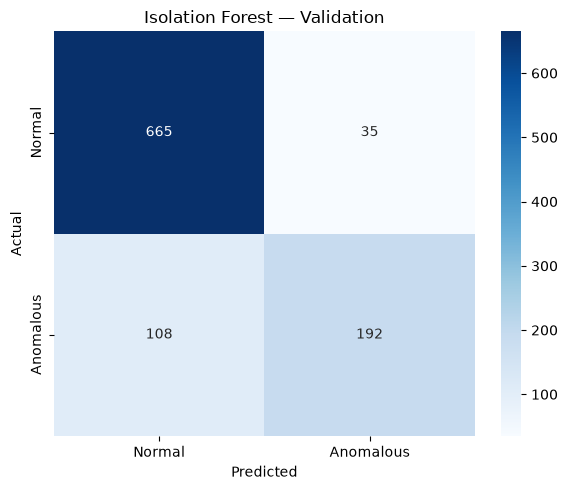

In [88]:
val_anomaly_cm = confusion_matrix(
    y_val,
    val_anomaly_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    val_anomaly_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomalous"],
    yticklabels=["Normal", "Anomalous"]
)

plt.title("Isolation Forest — Validation")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

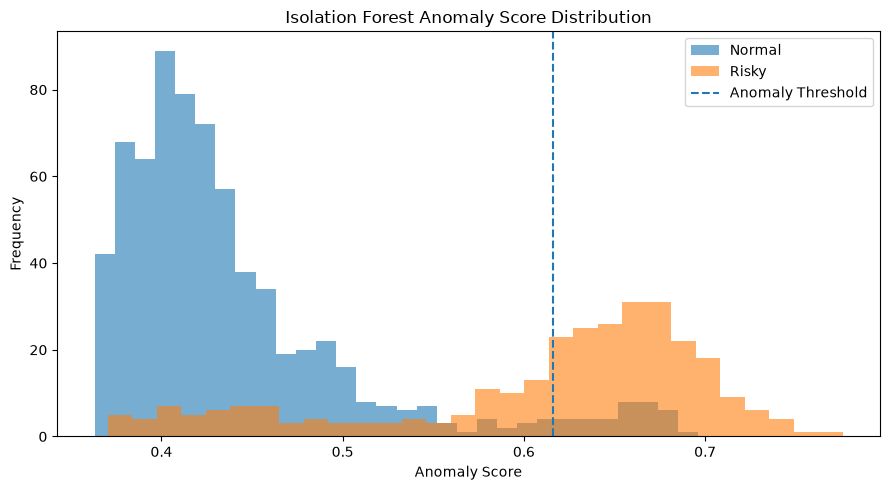

In [89]:
normal_val_scores = val_anomaly_scores[y_val.to_numpy() == 0]
risky_val_scores = val_anomaly_scores[y_val.to_numpy() == 1]

plt.figure(figsize=(9, 5))

plt.hist(
    normal_val_scores,
    bins=30,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    risky_val_scores,
    bins=30,
    alpha=0.6,
    label="Risky"
)

plt.axvline(
    ANOMALY_THRESHOLD,
    linestyle="--",
    label="Anomaly Threshold"
)

plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [90]:
X_dev_normal = X_dev[
    y_dev == 0
]

final_isolation_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

final_isolation_model.fit(X_dev_normal)

print(
    "Final Isolation Forest trained on",
    len(X_dev_normal),
    "normal development samples."
)

Final Isolation Forest trained on 6300 normal development samples.


In [91]:
final_anomaly_scores = anomaly_score(
    final_isolation_model,
    X_final_test
)

final_anomaly_predictions = (
    final_anomaly_scores >= ANOMALY_THRESHOLD
).astype(int)

In [92]:
final_anomaly_precision = precision_score(
    y_final_test,
    final_anomaly_predictions,
    zero_division=0
)

final_anomaly_recall = recall_score(
    y_final_test,
    final_anomaly_predictions,
    zero_division=0
)

final_anomaly_f1 = f1_score(
    y_final_test,
    final_anomaly_predictions,
    zero_division=0
)

print("======================================")
print("   CYBERTWIN FINAL ANOMALY DETECTOR")
print("======================================")
print(f"Threshold : {ANOMALY_THRESHOLD:.4f}")
print("--------------------------------------")
print(f"Precision : {final_anomaly_precision:.4f}")
print(f"Recall    : {final_anomaly_recall:.4f}")
print(f"F1 Score  : {final_anomaly_f1:.4f}")

   CYBERTWIN FINAL ANOMALY DETECTOR
Threshold : 0.6161
--------------------------------------
Precision : 0.8565
Recall    : 0.6167
F1 Score  : 0.7171


In [ ]:
# Phase 8 — Model Explainability

In [93]:
import shap

# Create SHAP TreeExplainer for our final Random Forest
explainer = shap.TreeExplainer(final_rf_model)

print("SHAP explainer created.")

SHAP explainer created.


In [94]:
shap_values = explainer.shap_values(X_final_test)

print("SHAP values generated.")
print(type(shap_values))

SHAP values generated.
<class 'numpy.ndarray'>


In [95]:
print("SHAP type:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of outputs:", len(shap_values))
    print("Risk-class SHAP shape:", shap_values[1].shape)
else:
    print("SHAP shape:", shap_values.shape)

SHAP type: <class 'numpy.ndarray'>
SHAP shape: (1000, 7, 2)


C:\Users\Siddhesh\AppData\Local\Temp\ipykernel_23988\1070780664.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
d:\Projects\CyberTwin_ML\.venv\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
d:\Projects\CyberTwin_ML\.venv\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


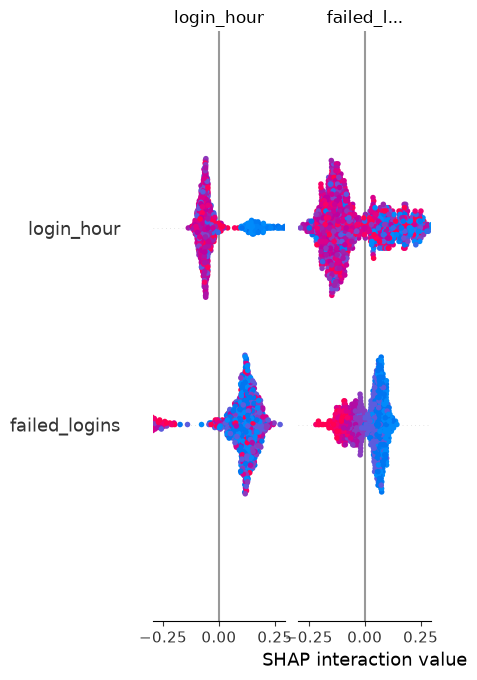

In [96]:
shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    X_final_test,
    feature_names=RAW_FEATURES
)

In [97]:
sample_index = 0

sample = X_final_test.iloc[[sample_index]]

print(sample)

      failed_logins  login_hour  new_devices  downloads_per_day  \
8532              3           7            1                 21   

      external_shares  sensitive_file_access  privilege_requests  
8532                1                      3                   0  


In [99]:
sample_index = 0

sample = X_final_test.iloc[[sample_index]]

print("Sample shape:", sample.shape)

sample_shap = explainer.shap_values(sample)

print("SHAP type:", type(sample_shap))

if isinstance(sample_shap, list):
    print("SHAP list length:", len(sample_shap))
    print("Each output shape:", [np.asarray(x).shape for x in sample_shap])
else:
    print("SHAP array shape:", np.asarray(sample_shap).shape)

Sample shape: (1, 7)
SHAP type: <class 'numpy.ndarray'>
SHAP array shape: (1, 7, 2)


In [100]:
sample_index = 0

sample = X_final_test.iloc[[sample_index]]

sample_shap = explainer.shap_values(sample)

# SHAP output shape:
# (samples, features, classes)
# We want class 1 = Risky
sample_shap_values = sample_shap[0, :, 1]

explanation = pd.DataFrame({
    "feature": RAW_FEATURES,
    "value": sample.iloc[0].values,
    "shap_value": sample_shap_values
})

explanation["absolute_impact"] = (
    explanation["shap_value"].abs()
)

explanation = explanation.sort_values(
    "absolute_impact",
    ascending=False
)

explanation

,feature,value,shap_value,absolute_impact
5,sensitive_file_access,3,-0.115587,0.115587
4,external_shares,1,-0.111917,0.111917
1,login_hour,7,-0.069880,0.069880
3,downloads_per_day,21,-0.044016,0.044016
2,new_devices,1,0.035878,0.035878
6,privilege_requests,0,-0.025952,0.025952
0,failed_logins,3,0.018665,0.018665


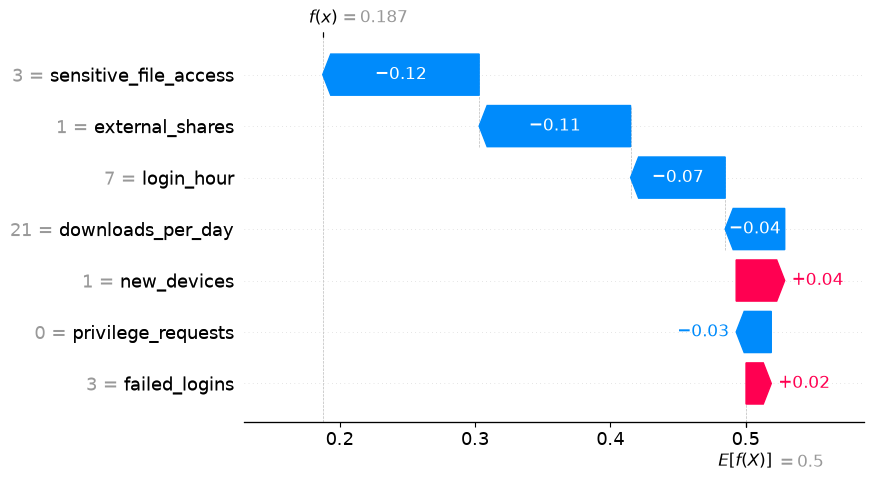

In [101]:
shap.plots.waterfall(
    shap.Explanation(
        values=sample_shap_values,
        base_values=explainer.expected_value[1],
        data=sample.iloc[0].values,
        feature_names=RAW_FEATURES
    ),
    max_display=7
)

In [134]:
def generate_reasons(explanation, top_n=3):
    top_features = explanation.head(top_n)

    reasons = []

    for _, row in top_features.iterrows():

        feature = row["feature"]
        value = row["value"]
        impact = row["shap_value"]

        # ----------------------------------------------------
        # Positive SHAP contribution
        # ----------------------------------------------------

        if impact > 0:

            if feature == "failed_logins":
                reason = (
                    f"{int(value)} failed login attempts "
                    f"increased risk"
                )

            elif feature == "login_hour":
                reason = (
                    f"Login at hour {int(value)} "
                    f"increased risk"
                )

            elif feature == "new_devices":
                reason = (
                    f"{int(value)} new device(s) "
                    f"increased risk"
                )

            elif feature == "downloads_per_day":
                reason = (
                    f"{int(value)} daily downloads "
                    f"increased risk"
                )

            elif feature == "external_shares":
                reason = (
                    f"{int(value)} external shares "
                    f"increased risk"
                )

            elif feature == "sensitive_file_access":
                reason = (
                    f"{int(value)} sensitive file accesses "
                    f"increased risk"
                )

            elif feature == "privilege_requests":
                reason = (
                    f"{int(value)} privilege requests "
                    f"increased risk"
                )

            else:
                reason = (
                    f"{feature} increased risk"
                )

        # ----------------------------------------------------
        # Negative SHAP contribution
        # ----------------------------------------------------

        else:

            if feature == "failed_logins":
                reason = (
                    f"Failed-login activity did not significantly "
                    f"contribute to the elevated risk"
                )

            elif feature == "login_hour":
                reason = (
                    f"Login timing did not significantly "
                    f"contribute to the elevated risk"
                )

            elif feature == "new_devices":
                reason = (
                    f"New-device activity did not significantly "
                    f"contribute to the elevated risk"
                )

            elif feature == "downloads_per_day":
                reason = (
                    f"Download activity did not significantly "
                    f"contribute to the elevated risk"
                )

            elif feature == "external_shares":
                reason = (
                    f"External sharing did not significantly "
                    f"contribute to the elevated risk"
                )

            elif feature == "sensitive_file_access":
                reason = (
                    f"Sensitive-file access did not significantly "
                    f"contribute to the elevated risk"
                )

            elif feature == "privilege_requests":
                reason = (
                    f"Privilege-request activity did not significantly "
                    f"contribute to the elevated risk"
                )

            else:
                reason = (
                    f"{feature} did not significantly "
                    f"contribute to the elevated risk"
                )

        reasons.append(reason)

    return reasons

In [103]:
reasons = generate_reasons(explanation, top_n=3)

print("TOP RISK FACTORS")
print("=================")

for i, reason in enumerate(reasons, start=1):
    print(f"{i}. {reason}")

TOP RISK FACTORS
1. 3 sensitive file accesses reduced risk
2. 1 external shares reduced risk
3. Login at hour 7 reduced risk


In [104]:
def explain_user_behavior(model, explainer, user_behavior):
    """
    Generate risk prediction and explanation
    for one user's behavioral data.
    """

    if isinstance(user_behavior, pd.Series):
        user_behavior = user_behavior.to_frame().T

    # Make sure feature order is correct
    user_behavior = user_behavior[RAW_FEATURES]

    # -----------------------------
    # 1. Risk probability
    # -----------------------------
    probability = model.predict_proba(
        user_behavior
    )[0, 1]

    prediction = int(
        probability >= FINAL_THRESHOLD
    )

    # -----------------------------
    # 2. SHAP explanation
    # -----------------------------
    shap_result = explainer.shap_values(
        user_behavior
    )

    shap_array = np.asarray(shap_result)

    # Current SHAP format:
    # (samples, features, classes)
    if shap_array.ndim == 3:
        shap_values_user = shap_array[0, :, 1]

    elif shap_array.ndim == 2:
        shap_values_user = shap_array[0]

    else:
        raise ValueError(
            f"Unexpected SHAP shape: {shap_array.shape}"
        )

    # -----------------------------
    # 3. Feature contribution table
    # -----------------------------
    explanation = pd.DataFrame({
        "feature": RAW_FEATURES,
        "value": user_behavior.iloc[0].values,
        "shap_value": shap_values_user
    })

    explanation["absolute_impact"] = (
        explanation["shap_value"].abs()
    )

    explanation = explanation.sort_values(
        "absolute_impact",
        ascending=False
    )

    # -----------------------------
    # 4. Human-readable reasons
    # -----------------------------
    reasons = generate_reasons(
        explanation,
        top_n=3
    )

    return {
        "risk_probability": float(probability),
        "risk_score": float(probability * 100),
        "prediction": prediction,
        "top_reasons": reasons,
        "feature_contributions": explanation
    }

In [105]:
result = explain_user_behavior(
    final_rf_model,
    explainer,
    X_final_test.iloc[0]
)

print("================================")
print("CYBERTWIN USER RISK EXPLANATION")
print("================================")

print(
    f"Risk Probability : "
    f"{result['risk_probability']:.4f}"
)

print(
    f"Risk Score       : "
    f"{result['risk_score']:.2f}/100"
)

print(
    f"Prediction       : "
    f"{'RISKY' if result['prediction'] == 1 else 'NORMAL'}"
)

print("\nTop Reasons:")

for reason in result["top_reasons"]:
    print("-", reason)

CYBERTWIN USER RISK EXPLANATION
Risk Probability : 0.1875
Risk Score       : 18.75/100
Prediction       : NORMAL

Top Reasons:
- 3 sensitive file accesses reduced risk
- 1 external shares reduced risk
- Login at hour 7 reduced risk


In [106]:
result["feature_contributions"]

,feature,value,shap_value,absolute_impact
5,sensitive_file_access,3,-0.115587,0.115587
4,external_shares,1,-0.111917,0.111917
1,login_hour,7,-0.069880,0.069880
3,downloads_per_day,21,-0.044016,0.044016
2,new_devices,1,0.035878,0.035878
6,privilege_requests,0,-0.025952,0.025952
0,failed_logins,3,0.018665,0.018665


In [107]:
for index in range(5):

    result = explain_user_behavior(
        final_rf_model,
        explainer,
        X_final_test.iloc[index]
    )

    print("\n" + "=" * 50)
    print(f"USER SAMPLE {index + 1}")
    print("=" * 50)

    print(
        f"Risk Score: "
        f"{result['risk_score']:.2f}/100"
    )

    print(
        "Prediction:",
        "RISKY" if result["prediction"] == 1 else "NORMAL"
    )

    print("Reasons:")

    for reason in result["top_reasons"]:
        print("-", reason)


USER SAMPLE 1
Risk Score: 18.75/100
Prediction: NORMAL
Reasons:
- 3 sensitive file accesses reduced risk
- 1 external shares reduced risk
- Login at hour 7 reduced risk

USER SAMPLE 2
Risk Score: 70.85/100
Prediction: RISKY
Reasons:
- 6 failed login attempts increased risk
- Login at hour 8 reduced risk
- 2 privilege requests increased risk

USER SAMPLE 3
Risk Score: 99.30/100
Prediction: RISKY
Reasons:
- 7 external shares increased risk
- Login at hour 5 increased risk
- 9 sensitive file accesses increased risk

USER SAMPLE 4
Risk Score: 6.76/100
Prediction: NORMAL
Reasons:
- 0 external shares reduced risk
- 0 failed login attempts reduced risk
- Login at hour 12 reduced risk

USER SAMPLE 5
Risk Score: 1.55/100
Prediction: NORMAL
Reasons:
- 1 sensitive file accesses reduced risk
- 0 external shares reduced risk
- 0 failed login attempts reduced risk


In [108]:
shap_values_test = explainer.shap_values(
    X_final_test
)

if isinstance(shap_values_test, list):
    shap_test_risky = shap_values_test[1]
else:
    shap_test_array = np.asarray(shap_values_test)

    if shap_test_array.ndim == 3:
        shap_test_risky = shap_test_array[:, :, 1]
    else:
        shap_test_risky = shap_test_array

In [109]:
global_shap_importance = pd.Series(
    np.abs(shap_test_risky).mean(axis=0),
    index=RAW_FEATURES
).sort_values(
    ascending=False
)

global_shap_importance

sensitive_file_access    0.115409
external_shares          0.106227
login_hour               0.076076
failed_logins            0.067742
downloads_per_day        0.054143
privilege_requests       0.030412
new_devices              0.019389
dtype: float64

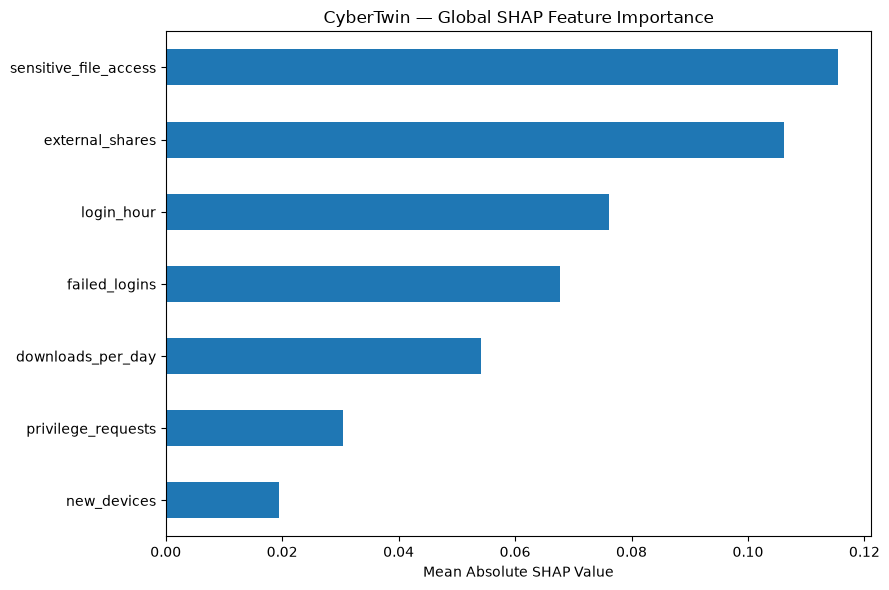

In [110]:
plt.figure(figsize=(9, 6))

global_shap_importance.sort_values().plot(
    kind="barh"
)

plt.title(
    "CyberTwin — Global SHAP Feature Importance"
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.tight_layout()
plt.show()

In [ ]:
# Phase 9 — Production Inference Pipeline

In [111]:
def get_risk_level(risk_score):
    if risk_score <= 30:
        return "LOW"
    elif risk_score <= 60:
        return "MEDIUM"
    elif risk_score <= 80:
        return "HIGH"
    else:
        return "CRITICAL"

In [112]:
for score in [10, 45, 70, 90]:
    print(score, "→", get_risk_level(score))

10 → LOW
45 → MEDIUM
70 → HIGH
90 → CRITICAL


In [113]:
def get_anomaly_status(anomaly_score):
    return anomaly_score >= ANOMALY_THRESHOLD

In [114]:
def predict_cybertwin_behavior(
    user_behavior,
    risk_model=final_rf_model,
    anomaly_model=final_isolation_model,
    shap_explainer=explainer
):
    """
    Complete CyberTwin ML inference pipeline.

    Input:
        One user's behavioral features.

    Output:
        Risk prediction, anomaly detection,
        and explainability information.
    """

    # --------------------------------
    # 1. Convert input to DataFrame
    # --------------------------------

    if isinstance(user_behavior, dict):
        user_behavior = pd.DataFrame([user_behavior])

    elif isinstance(user_behavior, pd.Series):
        user_behavior = user_behavior.to_frame().T

    # --------------------------------
    # 2. Validate required features
    # --------------------------------

    missing_features = [
        feature
        for feature in RAW_FEATURES
        if feature not in user_behavior.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing features: {missing_features}"
        )

    # Keep only the features used by our models
    model_input = user_behavior[RAW_FEATURES].copy()

    # --------------------------------
    # 3. Risk prediction
    # --------------------------------

    risk_probability = risk_model.predict_proba(
        model_input
    )[0, 1]

    risk_score = risk_probability * 100

    risk_level = get_risk_level(
        risk_score
    )

    is_risky = (
        risk_probability >= FINAL_THRESHOLD
    )

    # --------------------------------
    # 4. Anomaly detection
    # --------------------------------

    anomaly_score_value = float(
        anomaly_score(
            anomaly_model,
            model_input
        )[0]
    )

    is_anomalous = (
        anomaly_score_value >= ANOMALY_THRESHOLD
    )

    # --------------------------------
    # 5. SHAP explanation
    # --------------------------------

    shap_result = shap_explainer.shap_values(
        model_input
    )

    shap_array = np.asarray(
        shap_result
    )

    if shap_array.ndim == 3:
        shap_values_user = shap_array[0, :, 1]

    elif shap_array.ndim == 2:
        shap_values_user = shap_array[0]

    else:
        raise ValueError(
            f"Unexpected SHAP shape: {shap_array.shape}"
        )

    explanation = pd.DataFrame({
        "feature": RAW_FEATURES,
        "value": model_input.iloc[0].values,
        "shap_value": shap_values_user
    })

    explanation["absolute_impact"] = (
        explanation["shap_value"].abs()
    )

    explanation = explanation.sort_values(
        "absolute_impact",
        ascending=False
    )

    reasons = generate_reasons(
        explanation,
        top_n=3
    )

    # --------------------------------
    # 6. Return result
    # --------------------------------

    return {
        "risk_probability": round(
            float(risk_probability),
            4
        ),

        "risk_score": round(
            float(risk_score),
            2
        ),

        "risk_level": risk_level,

        "is_risky": bool(is_risky),

        "anomaly_score": round(
            anomaly_score_value,
            4
        ),

        "is_anomalous": bool(
            is_anomalous
        ),

        "top_reasons": reasons
    }

In [115]:
sample_user = X_final_test.iloc[0]

result = predict_cybertwin_behavior(
    sample_user
)

result

{'risk_probability': 0.1875,
 'risk_score': 18.75,
 'risk_level': 'LOW',
 'is_risky': False,
 'anomaly_score': 0.4324,
 'is_anomalous': False,
 'top_reasons': ['3 sensitive file accesses reduced risk',
  '1 external shares reduced risk',
  'Login at hour 7 reduced risk']}

In [116]:
sample_json = {
    "failed_logins": 8,
    "login_hour": 2,
    "new_devices": 2,
    "downloads_per_day": 450,
    "external_shares": 12,
    "sensitive_file_access": 17,
    "privilege_requests": 3
}

In [117]:
result = predict_cybertwin_behavior(
    sample_json
)

result

{'risk_probability': 0.9846,
 'risk_score': 98.46,
 'risk_level': 'CRITICAL',
 'is_risky': True,
 'anomaly_score': 0.7891,
 'is_anomalous': True,
 'top_reasons': ['12 external shares increased risk',
  'Login at hour 2 increased risk',
  '17 sensitive file accesses increased risk']}

In [118]:
normal_user = {
    "failed_logins": 0,
    "login_hour": 10,
    "new_devices": 0,
    "downloads_per_day": 20,
    "external_shares": 1,
    "sensitive_file_access": 2,
    "privilege_requests": 0
}

normal_result = predict_cybertwin_behavior(
    normal_user
)

normal_result

{'risk_probability': 0.0358,
 'risk_score': 3.58,
 'risk_level': 'LOW',
 'is_risky': False,
 'anomaly_score': 0.3882,
 'is_anomalous': False,
 'top_reasons': ['2 sensitive file accesses reduced risk',
  '1 external shares reduced risk',
  '0 failed login attempts reduced risk']}

In [119]:
suspicious_user = {
    "failed_logins": 10,
    "login_hour": 2,
    "new_devices": 3,
    "downloads_per_day": 700,
    "external_shares": 15,
    "sensitive_file_access": 25,
    "privilege_requests": 4
}

suspicious_result = predict_cybertwin_behavior(
    suspicious_user
)

suspicious_result

{'risk_probability': 0.9805,
 'risk_score': 98.05,
 'risk_level': 'CRITICAL',
 'is_risky': True,
 'anomaly_score': 0.8106,
 'is_anomalous': True,
 'top_reasons': ['Login at hour 2 increased risk',
  '15 external shares increased risk',
  '25 sensitive file accesses increased risk']}

In [120]:
comparison = pd.DataFrame([
    {
        "User": "Normal",
        "Risk Score": normal_result["risk_score"],
        "Risk Level": normal_result["risk_level"],
        "Anomaly Score": normal_result["anomaly_score"],
        "Anomalous": normal_result["is_anomalous"]
    },
    {
        "User": "Suspicious",
        "Risk Score": suspicious_result["risk_score"],
        "Risk Level": suspicious_result["risk_level"],
        "Anomaly Score": suspicious_result["anomaly_score"],
        "Anomalous": suspicious_result["is_anomalous"]
    }
])

comparison

,User,Risk Score,Risk Level,Anomaly Score,Anomalous
0,Normal,3.58,LOW,0.3882,False
1,Suspicious,98.05,CRITICAL,0.8106,True


In [121]:
import joblib
from pathlib import Path

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [122]:
joblib.dump(
    final_rf_model,
    MODEL_DIR / "risk_model.joblib"
)

['d:\\Projects\\CyberTwin_ML\\models\\risk_model.joblib']

In [123]:
joblib.dump(
    final_isolation_model,
    MODEL_DIR / "anomaly_model.joblib"
)

['d:\\Projects\\CyberTwin_ML\\models\\anomaly_model.joblib']

In [124]:
model_config = {
    "risk_threshold": FINAL_THRESHOLD,
    "anomaly_threshold": float(ANOMALY_THRESHOLD),
    "features": RAW_FEATURES
}

joblib.dump(
    model_config,
    MODEL_DIR / "model_config.joblib"
)

print("Models and configuration saved.")

Models and configuration saved.


In [125]:
print("NORMAL")
print(normal_result)

print("\nSUSPICIOUS")
print(suspicious_result)

NORMAL
{'risk_probability': 0.0358, 'risk_score': 3.58, 'risk_level': 'LOW', 'is_risky': False, 'anomaly_score': 0.3882, 'is_anomalous': False, 'top_reasons': ['2 sensitive file accesses reduced risk', '1 external shares reduced risk', '0 failed login attempts reduced risk']}

SUSPICIOUS
{'risk_probability': 0.9805, 'risk_score': 98.05, 'risk_level': 'CRITICAL', 'is_risky': True, 'anomaly_score': 0.8106, 'is_anomalous': True, 'top_reasons': ['Login at hour 2 increased risk', '15 external shares increased risk', '25 sensitive file accesses increased risk']}


In [126]:
import joblib

shap_config = {
    "expected_value": np.asarray(
        explainer.expected_value
    ).tolist()
}

joblib.dump(
    shap_config,
    MODEL_DIR / "shap_config.joblib"
)

print("SHAP configuration saved.")

SHAP configuration saved.


In [ ]:
# Final ML Validation

## 1. Robustness + Edge-Case Testing

In [127]:
robustness_cases = {
    "normal_user": {
        "failed_logins": 0,
        "login_hour": 10,
        "new_devices": 0,
        "downloads_per_day": 20,
        "external_shares": 1,
        "sensitive_file_access": 2,
        "privilege_requests": 0
    },

    "highly_suspicious_user": {
        "failed_logins": 15,
        "login_hour": 2,
        "new_devices": 4,
        "downloads_per_day": 1000,
        "external_shares": 25,
        "sensitive_file_access": 30,
        "privilege_requests": 5
    },

    "credential_attack": {
        "failed_logins": 15,
        "login_hour": 3,
        "new_devices": 2,
        "downloads_per_day": 20,
        "external_shares": 1,
        "sensitive_file_access": 2,
        "privilege_requests": 0
    },

    "data_exfiltration": {
        "failed_logins": 1,
        "login_hour": 14,
        "new_devices": 0,
        "downloads_per_day": 1000,
        "external_shares": 25,
        "sensitive_file_access": 30,
        "privilege_requests": 1
    },

    "privilege_abuse": {
        "failed_logins": 2,
        "login_hour": 2,
        "new_devices": 2,
        "downloads_per_day": 50,
        "external_shares": 2,
        "sensitive_file_access": 10,
        "privilege_requests": 8
    }
}

print(f"Created {len(robustness_cases)} test scenarios.")

Created 5 test scenarios.


In [137]:
robustness_results = []

for scenario_name, behavior in robustness_cases.items():

    result = predict_cybertwin_behavior(
        behavior
    )

    robustness_results.append({
        "Scenario": scenario_name,
        "Risk Score": result["risk_score"],
        "Risk Level": result["risk_level"],
        "Anomaly Score": result["anomaly_score"],
        "Anomalous": result["is_anomalous"],
        "Top Reasons": " | ".join(
            result["top_reasons"]
        )
    })

robustness_df = pd.DataFrame(
    robustness_results
)

robustness_df

,Scenario,Risk Score,Risk Level,Anomaly Score,Anomalous,Top Reasons
0,normal_user,3.58,LOW,0.3882,False,Sensitive-file access did not significantly co...
1,highly_suspicious_user,97.80,CRITICAL,0.8187,True,Login at hour 2 increased risk | 25 external s...
2,credential_attack,67.27,HIGH,0.6190,True,Login at hour 3 increased risk | 15 failed log...
3,data_exfiltration,70.77,HIGH,0.7254,True,30 sensitive file accesses increased risk | 25...
4,privilege_abuse,84.12,CRITICAL,0.6631,True,Login at hour 2 increased risk | 10 sensitive ...


In [129]:
minimum_case = {
    "failed_logins": 0,
    "login_hour": 0,
    "new_devices": 0,
    "downloads_per_day": 0,
    "external_shares": 0,
    "sensitive_file_access": 0,
    "privilege_requests": 0
}

minimum_result = predict_cybertwin_behavior(
    minimum_case
)

minimum_result

{'risk_probability': 0.2656,
 'risk_score': 26.56,
 'risk_level': 'LOW',
 'is_risky': False,
 'anomaly_score': 0.5372,
 'is_anomalous': False,
 'top_reasons': ['Login at hour 0 increased risk',
  '0 sensitive file accesses reduced risk',
  '0 external shares reduced risk']}

In [130]:
maximum_case = {
    "failed_logins": 100,
    "login_hour": 23,
    "new_devices": 50,
    "downloads_per_day": 10000,
    "external_shares": 100,
    "sensitive_file_access": 100,
    "privilege_requests": 50
}

maximum_result = predict_cybertwin_behavior(
    maximum_case
)

maximum_result

{'risk_probability': 0.9097,
 'risk_score': 90.97,
 'risk_level': 'CRITICAL',
 'is_risky': True,
 'anomaly_score': 0.8196,
 'is_anomalous': True,
 'top_reasons': ['100 sensitive file accesses increased risk',
  '100 external shares increased risk',
  '100 failed login attempts increased risk']}

In [138]:
print("==========================================")
print("CYBERTWIN ML ROBUSTNESS TEST")
print("==========================================")

for _, row in robustness_df.iterrows():

    print(f"\n{row['Scenario']}")

    print(f"Risk Score    : {row['Risk Score']}")
    print(f"Risk Level    : {row['Risk Level']}")
    print(f"Anomaly Score : {row['Anomaly Score']}")
    print(f"Anomalous     : {row['Anomalous']}")

    print("Reasons:")

    for reason in row["Top Reasons"].split(" | "):
        print(f"  • {reason}")

CYBERTWIN ML ROBUSTNESS TEST

normal_user
Risk Score    : 3.58
Risk Level    : LOW
Anomaly Score : 0.3882
Anomalous     : False
Reasons:
  • Sensitive-file access did not significantly contribute to the elevated risk
  • External sharing did not significantly contribute to the elevated risk
  • Failed-login activity did not significantly contribute to the elevated risk

highly_suspicious_user
Risk Score    : 97.8
Risk Level    : CRITICAL
Anomaly Score : 0.8187
Anomalous     : True
Reasons:
  • Login at hour 2 increased risk
  • 25 external shares increased risk
  • 30 sensitive file accesses increased risk

credential_attack
Risk Score    : 67.27
Risk Level    : HIGH
Anomaly Score : 0.619
Anomalous     : True
Reasons:
  • Login at hour 3 increased risk
  • 15 failed login attempts increased risk
  • Sensitive-file access did not significantly contribute to the elevated risk

data_exfiltration
Risk Score    : 70.77
Risk Level    : HIGH
Anomaly Score : 0.7254
Anomalous     : True
Reasons

In [ ]:
# 2. Model Performance and Latency Testing

In [139]:
import time

latency_input = {
    "failed_logins": 8,
    "login_hour": 2,
    "new_devices": 2,
    "downloads_per_day": 450,
    "external_shares": 12,
    "sensitive_file_access": 17,
    "privilege_requests": 3
}

# Warm-up run
predict_cybertwin_behavior(latency_input)

num_runs = 100

start_time = time.perf_counter()

for _ in range(num_runs):
    predict_cybertwin_behavior(latency_input)

end_time = time.perf_counter()

total_time = end_time - start_time

average_latency_ms = (
    total_time / num_runs
) * 1000

print("======================================")
print("CYBERTWIN ML LATENCY TEST")
print("======================================")
print(f"Runs            : {num_runs}")
print(f"Total time      : {total_time:.4f} seconds")
print(f"Average latency : {average_latency_ms:.2f} ms")

CYBERTWIN ML LATENCY TEST
Runs            : 100
Total time      : 11.8252 seconds
Average latency : 118.25 ms


In [140]:
import requests
import time

api_url = "http://127.0.0.1:8000/predict"

payload = {
    "user_id": "LATENCY_TEST",
    "failed_logins": 8,
    "login_hour": 2,
    "new_devices": 2,
    "downloads_per_day": 450,
    "external_shares": 12,
    "sensitive_file_access": 17,
    "privilege_requests": 3
}

# Warm-up
response = requests.post(
    api_url,
    json=payload
)

if response.status_code != 200:
    raise RuntimeError(
        f"Warm-up request failed: {response.status_code}"
    )

num_runs = 50

start_time = time.perf_counter()

for _ in range(num_runs):

    response = requests.post(
        api_url,
        json=payload
    )

    if response.status_code != 200:
        raise RuntimeError(
            f"API request failed: {response.status_code}"
        )

end_time = time.perf_counter()

total_api_time = end_time - start_time

average_api_latency_ms = (
    total_api_time / num_runs
) * 1000

print("======================================")
print("CYBERTWIN API LATENCY TEST")
print("======================================")
print(f"Runs            : {num_runs}")
print(f"Total time      : {total_api_time:.4f} seconds")
print(f"Average latency : {average_api_latency_ms:.2f} ms")

CYBERTWIN API LATENCY TEST
Runs            : 50
Total time      : 4.9613 seconds
Average latency : 99.23 ms


In [ ]:
# 3. Final Model Packaging & Version Metadata

In [141]:
from datetime import datetime

MODEL_VERSION = "1.0.0"

model_metadata = {
    "model_version": MODEL_VERSION,
    "risk_model": "RandomForestClassifier",
    "anomaly_model": "IsolationForest",
    "explainability": "SHAP",
    "risk_threshold": float(FINAL_THRESHOLD),
    "anomaly_threshold": float(ANOMALY_THRESHOLD),
    "features": RAW_FEATURES,
    "risk_levels": {
        "LOW": "0-30",
        "MEDIUM": "31-60",
        "HIGH": "61-80",
        "CRITICAL": "81-100"
    },
    "created_at": datetime.now().isoformat()
}

model_metadata

{'model_version': '1.0.0',
 'risk_model': 'RandomForestClassifier',
 'anomaly_model': 'IsolationForest',
 'explainability': 'SHAP',
 'risk_threshold': 0.55,
 'anomaly_threshold': 0.6160825033920516,
 'features': ['failed_logins',
  'login_hour',
  'new_devices',
  'downloads_per_day',
  'external_shares',
  'sensitive_file_access',
  'privilege_requests'],
 'risk_levels': {'LOW': '0-30',
  'MEDIUM': '31-60',
  'HIGH': '61-80',
  'CRITICAL': '81-100'},
 'created_at': '2026-08-16T16:35:22.377567'}

In [142]:
metadata_path = MODEL_DIR / "model_metadata.joblib"

joblib.dump(
    model_metadata,
    metadata_path
)

print(
    f"Model metadata saved to: {metadata_path}"
)

Model metadata saved to: d:\Projects\CyberTwin_ML\models\model_metadata.joblib


In [143]:
print("======================================")
print("FINAL MODEL ARTIFACT CHECK")
print("======================================")

artifacts = [
    "risk_model.joblib",
    "anomaly_model.joblib",
    "model_config.joblib",
    "model_metadata.joblib"
]

for filename in artifacts:

    path = MODEL_DIR / filename

    if path.exists():

        try:
            loaded_object = joblib.load(path)

            print(f"✅ {filename} — LOADABLE")

        except Exception as e:

            print(f"❌ {filename} — FAILED")
            print(f"   Error: {e}")

    else:

        print(f"❌ {filename} — MISSING")

FINAL MODEL ARTIFACT CHECK
✅ risk_model.joblib — LOADABLE
✅ anomaly_model.joblib — LOADABLE
✅ model_config.joblib — LOADABLE
✅ model_metadata.joblib — LOADABLE


In [144]:
loaded_rf = joblib.load(
    MODEL_DIR / "risk_model.joblib"
)

loaded_iforest = joblib.load(
    MODEL_DIR / "anomaly_model.joblib"
)

loaded_config = joblib.load(
    MODEL_DIR / "model_config.joblib"
)

loaded_metadata = joblib.load(
    MODEL_DIR / "model_metadata.joblib"
)

print("\nLoaded model types:")
print(type(loaded_rf).__name__)
print(type(loaded_iforest).__name__)

print("\nModel version:")
print(loaded_metadata["model_version"])

print("\nRisk threshold:")
print(loaded_config["risk_threshold"])

print("\nAnomaly threshold:")
print(loaded_config["anomaly_threshold"])


Loaded model types:
RandomForestClassifier
IsolationForest

Model version:
1.0.0

Risk threshold:
0.55

Anomaly threshold:
0.6160825033920516


In [ ]:
# 4. SIH Demonstration Scenarios

In [145]:
sih_scenarios = {

    "Normal Employee": {
        "failed_logins": 0,
        "login_hour": 10,
        "new_devices": 0,
        "downloads_per_day": 20,
        "external_shares": 1,
        "sensitive_file_access": 2,
        "privilege_requests": 0
    },

    "Credential Compromise": {
        "failed_logins": 12,
        "login_hour": 3,
        "new_devices": 2,
        "downloads_per_day": 25,
        "external_shares": 1,
        "sensitive_file_access": 3,
        "privilege_requests": 0
    },

    "Data Exfiltration": {
        "failed_logins": 1,
        "login_hour": 14,
        "new_devices": 0,
        "downloads_per_day": 850,
        "external_shares": 22,
        "sensitive_file_access": 28,
        "privilege_requests": 1
    },

    "Privilege Abuse": {
        "failed_logins": 2,
        "login_hour": 2,
        "new_devices": 2,
        "downloads_per_day": 50,
        "external_shares": 2,
        "sensitive_file_access": 12,
        "privilege_requests": 8
    },

    "Multi-Stage Compromise": {
        "failed_logins": 10,
        "login_hour": 2,
        "new_devices": 3,
        "downloads_per_day": 700,
        "external_shares": 18,
        "sensitive_file_access": 25,
        "privilege_requests": 5
    }
}

print(
    f"Created {len(sih_scenarios)} SIH scenarios."
)

Created 5 SIH scenarios.


In [146]:
sih_results = []

for scenario_name, behavior in sih_scenarios.items():

    result = predict_cybertwin_behavior(
        behavior
    )

    sih_results.append({
        "Scenario": scenario_name,
        "Risk Score": result["risk_score"],
        "Risk Level": result["risk_level"],
        "Anomaly Score": result["anomaly_score"],
        "Anomalous": result["is_anomalous"],
        "Top Reasons": " | ".join(
            result["top_reasons"]
        )
    })

sih_results_df = pd.DataFrame(
    sih_results
)

sih_results_df

,Scenario,Risk Score,Risk Level,Anomaly Score,Anomalous,Top Reasons
0,Normal Employee,3.58,LOW,0.3882,False,Sensitive-file access did not significantly co...
1,Credential Compromise,66.99,HIGH,0.6231,True,Login at hour 3 increased risk | 12 failed log...
2,Data Exfiltration,70.87,HIGH,0.7254,True,28 sensitive file accesses increased risk | 22...
3,Privilege Abuse,83.68,CRITICAL,0.6865,True,Login at hour 2 increased risk | 12 sensitive ...
4,Multi-Stage Compromise,98.25,CRITICAL,0.8137,True,Login at hour 2 increased risk | 25 sensitive ...


In [147]:
print("======================================================")
print("          CYBERTWIN SIH DEMONSTRATION")
print("======================================================")

for scenario_name, behavior in sih_scenarios.items():

    result = predict_cybertwin_behavior(
        behavior
    )

    print("\n" + "=" * 54)
    print(f"SCENARIO: {scenario_name}")
    print("=" * 54)

    print(
        f"Risk Score    : "
        f"{result['risk_score']:.2f}/100"
    )

    print(
        f"Risk Level    : "
        f"{result['risk_level']}"
    )

    print(
        f"Anomaly Score : "
        f"{result['anomaly_score']:.4f}"
    )

    print(
        f"Anomalous     : "
        f"{result['is_anomalous']}"
    )

    print("\nWhy?")

    for reason in result["top_reasons"]:
        print(f"  • {reason}")

          CYBERTWIN SIH DEMONSTRATION

SCENARIO: Normal Employee
Risk Score    : 3.58/100
Risk Level    : LOW
Anomaly Score : 0.3882
Anomalous     : False

Why?
  • Sensitive-file access did not significantly contribute to the elevated risk
  • External sharing did not significantly contribute to the elevated risk
  • Failed-login activity did not significantly contribute to the elevated risk

SCENARIO: Credential Compromise
Risk Score    : 66.99/100
Risk Level    : HIGH
Anomaly Score : 0.6231
Anomalous     : True

Why?
  • Login at hour 3 increased risk
  • 12 failed login attempts increased risk
  • Sensitive-file access did not significantly contribute to the elevated risk

SCENARIO: Data Exfiltration
Risk Score    : 70.87/100
Risk Level    : HIGH
Anomaly Score : 0.7254
Anomalous     : True

Why?
  • 28 sensitive file accesses increased risk
  • 22 external shares increased risk
  • Failed-login activity did not significantly contribute to the elevated risk

SCENARIO: Privilege Abus

In [ ]:
# 5. Final ML Documentation

## CyberTwin ML Architecture

CyberTwin uses a multi-layer behavioral intelligence approach consisting of:

1. Random Forest — supervised behavioral risk classification.
2. Isolation Forest — unsupervised anomaly detection.
3. SHAP — explainable per-user risk attribution.

## Input Features

The ML engine analyzes seven behavioral features:

- failed_logins
- login_hour
- new_devices
- downloads_per_day
- external_shares
- sensitive_file_access
- privilege_requests

## Risk Classification

Random Forest produces a probability of risky behavior.

The selected classification threshold is:

0.55

Risk levels:

- 0–30: LOW
- 31–60: MEDIUM
- 61–80: HIGH
- 81–100: CRITICAL

## Anomaly Detection

Isolation Forest learns the distribution of normal behavioral activity.

Final anomaly threshold:

0.6160825033920516

A score at or above this threshold is classified as anomalous.

Important: the anomaly score is a relative anomaly measure, not a probability.

## Explainability

SHAP is used to identify the behavioral features that contributed most strongly to an individual user's risk prediction.

The system converts these contributions into human-readable reasons.

Example:

- Multiple failed login attempts increased risk.
- High external sharing increased risk.
- High sensitive-file access increased risk.

## Model Version

Version: 1.0.0

Risk Model: Random Forest

Anomaly Model: Isolation Forest

Explainability: SHAP

## API

The ML engine is exposed through a FastAPI service.

Primary endpoint:

POST /predict

The API accepts user behavioral features and returns:

- risk probability
- risk score
- risk level
- risky classification
- anomaly score
- anomaly status
- top risk reasons

## Important Dataset Limitation

The current prototype is trained and evaluated on a simulated enterprise behavioral dataset.

Therefore, the reported performance demonstrates prototype capability and internal validation, not real-world attack-detection accuracy.

Real-world deployment would require validation and retraining using representative enterprise telemetry.